# 02_analysis — Segmentation & Profil d'effort

## Objectif
- Segmenter la trace en **étapes officielles GR65** (Le Puy → Saint-Jean-Pied-de-Port)
- Proposer une **segmentation intelligente** ancrée sur les hébergements réels (cf. note ci-dessous)
- Calculer un **score d'effort composite** (D+ normalisé 60% + distance normalisée 40%) par étape
- Exporter deux CSV d'étapes pour le dashboard (Phase 4)

## Dépendances
- `data_raw/profile_srtm.csv` — 14 765 points GPX enrichis *(produit par 00_explore_gpx)*
- `data_raw/hebergements.csv` — hébergements OSM filtrés à 1 km de la trace *(produit par 01_hebergements)*

## Sorties
- `data_raw/etapes_officielles.csv` — 1 ligne par étape GR65 officielle
- `data_raw/etapes_custom.csv` — 1 ligne par étape personnalisée, ancrée sur un hébergement réel

---

## Note de conception — Ordre des notebooks et biais identifiés

### Ordre initialement envisagé
La segmentation personnalisable devait être produite **avant** la collecte des hébergements,
en découpant la trace par distance cible fixe (ex : 25 km/jour).

### Biais identifiés
Ce découpage purement mathématique pose deux problèmes :

1. **Coupure en terrain vide** — une étape de 25 km peut se terminer en pleine forêt ou
   sur un causse, là où aucun hébergement n'existe. Le point de coupure ne correspond
   à aucune réalité de terrain pour le pèlerin.

2. **Propagation du biais en cascade** — toute analyse construite sur ces étapes artificielles
   (profil d'effort, score de difficulté, dashboard) hérite du même problème.

### Décision retenue
Ce notebook est positionné **après** `01_hebergements`. La segmentation personnalisable
utilise une fenêtre `[KM_MIN, KM_MAX]` pour trouver le prochain hébergement disponible,
garantissant que chaque étape commence et se termine dans un lieu où le pèlerin peut dormir.
Les **étapes officielles GR65** sont conservées telles quelles — elles ont été établies
précisément en tenant compte de la localisation des hébergements.

> **Run All autorisé** — nécessite d'avoir exécuté `01_hebergements` au préalable.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from pathlib import Path

# ── Chemins relatifs (portables sur toute machine) ─────────────────────────
BASE          = Path("C:/Users/cello/Desktop/Via_Podiensis_geospatial/data_raw")
PROFILE_CSV   = BASE / "profile_srtm.csv"
HEBERGS_CSV   = BASE / "hebergements.csv"
OUT_OFFICIEL  = BASE / "etapes_officielles.csv"
OUT_CUSTOM    = BASE / "etapes_custom.csv"
OUT_FIG_EFFORT = BASE / "profil_effort.png"
OUT_FIG_ALTI   = BASE / "profil_altimetrique.png"

# ── Vérification des fichiers sources ─────────────────────────────────────
for f in [PROFILE_CSV, HEBERGS_CSV]:
    if not f.exists():
        raise FileNotFoundError(f"Fichier manquant : {f}\nVérifiez l'exécution des notebooks précédents.")

# ── Chargement ─────────────────────────────────────────────────────────────
df   = pd.read_csv(PROFILE_CSV)
df_h = pd.read_csv(HEBERGS_CSV).sort_values("km_sur_trace").reset_index(drop=True)

df["elevation_diff"] = pd.to_numeric(df["elevation_diff"], errors="coerce").fillna(0)
df["slope"]          = pd.to_numeric(df["slope"],          errors="coerce").fillna(0)

TOTAL_KM = df["distance_m"].max() / 1000
print(f"Trace chargée        : {len(df):,} points — {TOTAL_KM:.1f} km")
print(f"Hébergements chargés : {len(df_h):,} (km {df_h['km_sur_trace'].min():.1f} → {df_h['km_sur_trace'].max():.1f})")
df.head(3)

Trace chargée        : 14,765 points — 744.6 km
Hébergements chargés : 403 (km 0.0 → 744.6)


,lon,lat,time,elevation,distance_m,place_name,elevation_diff,slope
0,3.88478,45.04559,NaN,680.0,0.000000,Le Puy-en-Velay,0.0,0.000000
1,3.88396,45.04557,NaN,662.0,64.460946,Le Puy-en-Velay,-18.0,-0.279239
2,3.88319,45.04553,NaN,652.0,125.118634,Le Puy-en-Velay,-10.0,-0.164860


## 1. Fonction de calcul des statistiques par étape

Fonction centrale réutilisée pour les deux modes de segmentation.
Chaque étape est définie par une borne kilométrique de départ ; la borne de fin est la borne suivante.

**Score d'effort composite** : `0.6 × D+_normalisé + 0.4 × distance_normalisée`  
La pondération favorise le dénivelé, déterminant majeur de la fatigue sur ce type de parcours.
La classification Facile / Modéré / Difficile est établie par tertiles sur l'ensemble des étapes.

In [2]:
def compute_etape_stats(df, bornes_km):
    """
    Calcule les statistiques de chaque étape définie par `bornes_km`.

    Parameters
    ----------
    df        : DataFrame GPX avec colonnes distance_m, elevation, elevation_diff, slope
    bornes_km : list of (str, float) — (nom_ville, km_depart)

    Returns
    -------
    DataFrame avec 1 ligne par étape, score d'effort et niveau de difficulté.
    """
    records = []
    dist_km = df["distance_m"] / 1000  # calculé une fois hors de la boucle

    for i, (nom, km_start) in enumerate(bornes_km):
        km_end = bornes_km[i + 1][1] if i + 1 < len(bornes_km) else TOTAL_KM
        seg    = df[(dist_km >= km_start) & (dist_km < km_end)]

        if seg.empty:
            continue

        d_plus  = seg.loc[seg["elevation_diff"] > 0, "elevation_diff"].sum()
        d_minus = seg.loc[seg["elevation_diff"] < 0, "elevation_diff"].sum()

        records.append({
            "etape"        : i + 1,
            "depart"       : nom,
            "arrivee"      : bornes_km[i + 1][0] if i + 1 < len(bornes_km) else "Arrivée",
            "distance_km"  : round(km_end - km_start, 1),
            "d_plus_m"     : round(d_plus, 0),
            "d_minus_m"    : round(abs(d_minus), 0),
            "alt_min_m"    : round(seg["elevation"].min(), 0),
            "alt_max_m"    : round(seg["elevation"].max(), 0),
            "pente_moy_pct": round(seg["slope"].abs().median() * 100, 1),
            "km_start"     : km_start,
            "km_end"       : km_end,
        })

    result = pd.DataFrame(records)

    # Score d'effort composite (D+ pondéré à 60%, distance à 40%)
    result["score_effort"] = (
        0.6 * (result["d_plus_m"]    / result["d_plus_m"].max()) +
        0.4 * (result["distance_km"] / result["distance_km"].max())
    ).round(3)

    # Classification par tertiles
    q33, q66 = result["score_effort"].quantile([0.33, 0.66])
    result["difficulte"] = pd.cut(
        result["score_effort"],
        bins=[-np.inf, q33, q66, np.inf],
        labels=["Facile", "Modéré", "Difficile"]
    )

    return result

## 2. Géocodage automatique des villes-étapes GR65

Plutôt que de coder les distances kilométriques à la main — source d'erreurs comme
l'illustre l'étape Saugues → Saint-Alban initialement donnée pour 24 km au lieu de 34 km —
on **géocode chaque ville-étape via Photon** pour obtenir ses coordonnées GPS,
puis on trouve le **point GPX le plus proche** sur la trace et on lit son `distance_m`.

Cette approche garantit que les bornes kilométriques sont cohérentes avec le tracé réel,
sans aucune valeur saisie manuellement.

> La cellule effectue 32 appels Photon (~35 secondes). Les résultats sont mis en cache
> dans `data_raw/geocode_etapes_cache.json` pour les relances suivantes.

In [3]:
import requests
import time
import json
import numpy as np

PHOTON_URL   = "https://photon.komoot.io/api/"
CACHE_ETAPES = BASE / "geocode_etapes_cache.json"

# Villes-étapes officielles GR65 — ordre seul, km calculés automatiquement
VILLES_ETAPES = [
    "Le Puy-en-Velay",
    "Saint-Privat-d'Allier",
    "Saugues",
    "Saint-Alban-sur-Limagnole",
    "Aumont-Aubrac",
    "Nasbinals",
    "Saint-Chély-d'Aubrac",
    "Saint-Côme-d'Olt",
    "Espalion",
    "Estaing",
    "Golinhac",
    "Conques",
    "Decazeville",
    "Figeac",
    "Cajarc",
    "Limogne-en-Quercy",
    "Cahors",
    "Lauzerte",
    "Moissac",
    "Auvillar",
    "Lectoure",
    "Condom",
    "Éauze",
    "Nogaro",
    "Aire-sur-l'Adour",
    "Miramont-Sensacq",
    "Arzacq-Arraziguet",
    "Arthez-de-Béarn",
    "Navarrenx",
    "Aroue",
    "Saint-Palais",
    "Ostabat-Asmé",
    "Saint-Jean-Pied-de-Port",
]


def geocode_ville(nom, session, cache):
    """Géocode une ville via Photon. Retourne (lat, lon) ou None."""
    if nom in cache:
        return tuple(cache[nom])
    try:
        r = session.get(
            PHOTON_URL,
            params={"q": nom + " France", "limit": 1, "lang": "fr"},
            headers={"User-Agent": "ViaPodiensisProject/1.0"},
            timeout=10
        )
        r.raise_for_status()
        features = r.json().get("features", [])
        if not features:
            print(f"  [WARN] Ville non trouvée : {nom}")
            return None
        coords = features[0]["geometry"]["coordinates"]  # [lon, lat]
        result = (coords[1], coords[0])  # -> (lat, lon)
        cache[nom] = list(result)
        time.sleep(0.5)
        return result
    except Exception as e:
        print(f"  [ERROR] {nom} : {e}")
        return None


def nearest_km(lat, lon, df):
    """Retourne le km cumulé du point GPX le plus proche de (lat, lon)."""
    dists = np.sqrt((df["lat"] - lat)**2 + (df["lon"] - lon)**2)
    return round(df.loc[dists.idxmin(), "distance_m"] / 1000, 1)


# Chargement du cache disque
cache = json.loads(CACHE_ETAPES.read_text(encoding="utf-8")) if CACHE_ETAPES.exists() else {}
session = requests.Session()

print("Géocodage des villes-étapes...")
ETAPES_OFFICIELLES = []
echecs = []

for ville in VILLES_ETAPES:
    coords = geocode_ville(ville, session, cache)
    if coords is None:
        echecs.append(ville)
        continue
    km = nearest_km(coords[0], coords[1], df)
    ETAPES_OFFICIELLES.append((ville, km))
    print(f"  {ville:<35} -> km {km:6.1f}")

# Sauvegarde du cache
CACHE_ETAPES.write_text(json.dumps(cache, ensure_ascii=False, indent=2), encoding="utf-8")

# Tri par km croissant (sécurité si Photon retourne un résultat lointain)
ETAPES_OFFICIELLES.sort(key=lambda x: x[1])

print(f"\n{len(ETAPES_OFFICIELLES)} villes géocodées")
if echecs:
    print(f"\n[WARN] Echecs ({len(echecs)}) : {echecs}")
    print("   Renseignez manuellement le km de ces villes dans OVERRIDES (cellule suivante)")


Géocodage des villes-étapes...
  Le Puy-en-Velay                     -> km    0.0
  Saint-Privat-d'Allier               -> km   23.4
  Saugues                             -> km   42.9
  Saint-Alban-sur-Limagnole           -> km   75.2
  Aumont-Aubrac                       -> km   91.1
  Nasbinals                           -> km  116.2
  Saint-Chély-d'Aubrac                -> km  132.6
  Saint-Côme-d'Olt                    -> km  148.8
  Espalion                            -> km  157.0
  Estaing                             -> km  626.3
  Golinhac                            -> km  183.6
  Conques                             -> km  204.1
  Decazeville                         -> km  221.9
  Figeac                              -> km  250.9
  Cajarc                              -> km  281.6
  Limogne-en-Quercy                   -> km  299.5
  Cahors                              -> km  340.0
  Lauzerte                            -> km  388.0
  Moissac                             -> km  414.7


### Vérification des bornes calculées

Tableau de lecture des km calculés par géocodage Photon.
Si une ville vous semble mal positionnée sur le tracé, renseignez sa correction
dans `OVERRIDES` (cellule suivante).

In [4]:
print(f"{'#':<5} {'Ville':<35} {'km debut':>8} {'km etape':>9}")
print("-" * 58)
for i, (ville, km) in enumerate(ETAPES_OFFICIELLES):
    if i + 1 < len(ETAPES_OFFICIELLES):
        km_etape = ETAPES_OFFICIELLES[i + 1][1] - km
        print(f"{i+1:<5} {ville:<35} {km:>8.1f} {km_etape:>9.1f}")
    else:
        print(f"{i+1:<5} {ville:<35} {km:>8.1f} {'(fin)':>9}")


#     Ville                               km debut  km etape
----------------------------------------------------------
1     Le Puy-en-Velay                          0.0      23.4
2     Saint-Privat-d'Allier                   23.4      19.5
3     Saugues                                 42.9      32.3
4     Saint-Alban-sur-Limagnole               75.2      15.9
5     Aumont-Aubrac                           91.1      25.1
6     Nasbinals                              116.2      16.4
7     Saint-Chély-d'Aubrac                   132.6      16.2
8     Saint-Côme-d'Olt                       148.8       8.2
9     Espalion                               157.0      26.6
10    Golinhac                               183.6      20.5
11    Conques                                204.1      17.8
12    Decazeville                            221.9      29.0
13    Figeac                                 250.9      30.7
14    Cajarc                                 281.6      17.9
15    Limogne-en-Quercy   

### Corrections manuelles et calcul final

Remplissez `OVERRIDES` uniquement si la validation a signalé des anomalies.
Laissez-le vide sinon — les bornes Photon sont utilisées telles quelles.

In [5]:
# ── Corrections manuelles éventuelles ─────────────────────────────────────
# Exemple : OVERRIDES = {"Nasbinals": 115.0}
OVERRIDES = {}
# ──────────────────────────────────────────────────────────────────────────

if OVERRIDES:
    ETAPES_OFFICIELLES = [
        (ville, OVERRIDES.get(ville, km))
        for ville, km in ETAPES_OFFICIELLES
    ]
    ETAPES_OFFICIELLES.sort(key=lambda x: x[1])
    print(f"Overrides appliques : {list(OVERRIDES.keys())}")
else:
    print("Aucun override — bornes Photon utilisees.")

df_officielles = compute_etape_stats(df, ETAPES_OFFICIELLES)
print(f"\n{len(df_officielles)} etapes calculees")
df_officielles[["etape", "depart", "arrivee", "distance_km", "d_plus_m", "score_effort", "difficulte"]]


Aucun override — bornes Photon utilisees.

32 etapes calculees


,etape,depart,arrivee,distance_km,d_plus_m,score_effort,difficulte
0,1,Le Puy-en-Velay,Saint-Privat-d'Allier,23.4,842.0,0.510,Modéré
1,2,Saint-Privat-d'Allier,Saugues,19.5,1168.0,0.600,Difficile
2,3,Saugues,Saint-Alban-sur-Limagnole,32.3,1153.0,0.701,Difficile
3,4,Saint-Alban-sur-Limagnole,Aumont-Aubrac,15.9,604.0,0.359,Facile
4,5,Aumont-Aubrac,Nasbinals,25.1,675.0,0.462,Modéré
5,6,Nasbinals,Saint-Chély-d'Aubrac,16.4,668.0,0.387,Modéré
6,7,Saint-Chély-d'Aubrac,Saint-Côme-d'Olt,16.2,715.0,0.403,Modéré
7,8,Saint-Côme-d'Olt,Espalion,8.2,410.0,0.222,Facile
8,9,Espalion,Golinhac,26.6,1602.0,0.822,Difficile
9,10,Golinhac,Conques,20.5,965.0,0.532,Modéré


## 3. Segmentation intelligente (ancrée sur les hébergements réels)

**Principe** : pour une fourchette `[KM_MIN, KM_MAX]` définie par le pèlerin,
l'algorithme cherche le prochain hébergement disponible dans cette fenêtre.
Si aucun hébergement n'existe dans la fenêtre, il prend le plus proche au-delà de `KM_MIN`
et affiche un avertissement — ce cas signale une zone peu équipée sur le tracé.

**Paramètres à modifier** : `KM_MIN` et `KM_MAX` ci-dessous.

In [6]:
# ── Paramètres à modifier selon votre rythme ──────────────────────────────
KM_MIN = 20   # distance minimale d'une étape (km)
KM_MAX = 30   # distance maximale d'une étape (km)
# ──────────────────────────────────────────────────────────────────────────

bornes_km_custom = [("Le Puy-en-Velay", 0.0)]
current_km       = 0.0
warnings         = []

while current_km < TOTAL_KM - KM_MIN:
    # Hébergements dans la fenêtre cible
    candidats = df_h[
        (df_h["km_sur_trace"] > current_km + KM_MIN) &
        (df_h["km_sur_trace"] <= current_km + KM_MAX)
    ]

    if candidats.empty:
        # Aucun hébergement dans la fenêtre → prendre le plus proche au-delà de KM_MIN
        candidats = df_h[df_h["km_sur_trace"] > current_km + KM_MIN]
        if candidats.empty:
            break
        next_stop = candidats.iloc[0]
        msg = (f"⚠️  Aucun hébergement entre km {current_km+KM_MIN:.0f} "
               f"et {current_km+KM_MAX:.0f} — "
               f"prochain : {next_stop['nom']} (km {next_stop['km_sur_trace']:.1f})")
        warnings.append(msg)
        print(msg)
    else:
        # Hébergement le plus proche du centre de la fenêtre
        cible     = current_km + (KM_MIN + KM_MAX) / 2
        next_stop = candidats.iloc[(candidats["km_sur_trace"] - cible).abs().argsort().iloc[0]]

    bornes_km_custom.append((next_stop["nom"], next_stop["km_sur_trace"]))
    current_km = next_stop["km_sur_trace"]

df_custom = compute_etape_stats(df, bornes_km_custom)

print(f"\n→ {len(df_custom)} étapes générées dans la fourchette [{KM_MIN}–{KM_MAX} km]")
print(f"  Distance moy/étape : {df_custom['distance_km'].mean():.1f} km")
print(f"  D+ moyen/étape     : {df_custom['d_plus_m'].mean():.0f} m")
if warnings:
    print(f"  {len(warnings)} zone(s) sans hébergement dans la fenêtre cible — voir avertissements ci-dessus")
df_custom[["etape", "depart", "arrivee", "distance_km", "d_plus_m", "score_effort", "difficulte"]].head(10)

⚠️  Aucun hébergement entre km 681 et 691 — prochain : À Deux Pas du Chemin (km 697.6)

→ 29 étapes générées dans la fourchette [20–30 km]
  Distance moy/étape : 25.7 km
  D+ moyen/étape     : 814 m
  1 zone(s) sans hébergement dans la fenêtre cible — voir avertissements ci-dessus


,etape,depart,arrivee,distance_km,d_plus_m,score_effort,difficulte
0,1,Le Puy-en-Velay,Refuge Municipal Accueil Pelerin,24.7,939.0,0.655,Modéré
1,2,Refuge Municipal Accueil Pelerin,Gîte Compostella,25.5,1332.0,0.826,Difficile
2,3,Gîte Compostella,Gîte d'étape Communal,25.0,892.0,0.639,Modéré
3,4,Gîte d'étape Communal,Gîte Communal,25.7,895.0,0.648,Modéré
4,5,Gîte Communal,La Cassagnolle,24.4,784.0,0.588,Modéré
5,6,La Cassagnolle,Gite d Etape l'Estaou,23.7,987.0,0.664,Difficile
6,7,Gite d Etape l'Estaou,N'Atura Hôtel,23.5,1141.0,0.726,Difficile
7,8,N'Atura Hôtel,Bidean,22.0,1454.0,0.838,Difficile
8,9,Bidean,L'Ancien Carmel de Condom,27.4,1238.0,0.808,Difficile
9,10,L'Ancien Carmel de Condom,Le Commerce,27.2,1028.0,0.719,Difficile


## 4. Visualisation — Profil d'effort par étape officielle

Trois métriques empilées pour chaque étape, colorées par score d'effort (vert → rouge).  
La lecture combinée des trois graphiques permet d'identifier les étapes physiquement exigeantes
indépendamment de leur longueur.

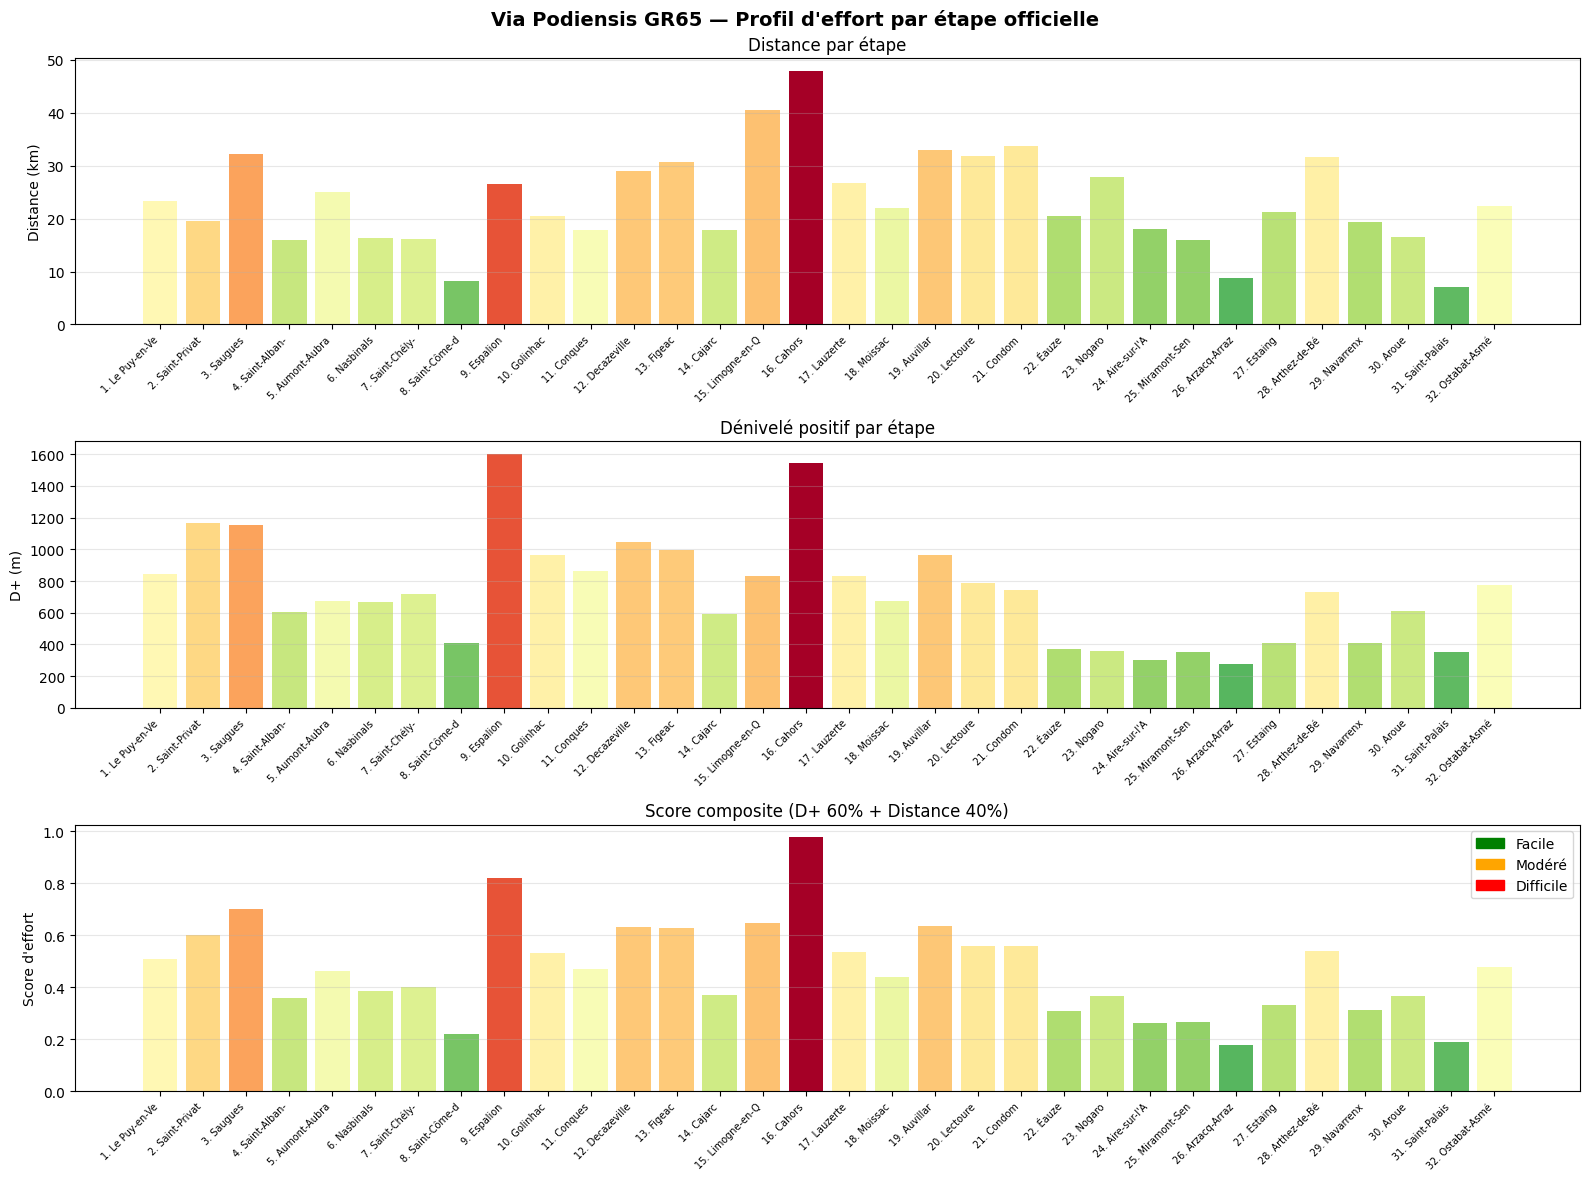

Graphique exporté : C:\Users\cello\Desktop\Via_Podiensis_geospatial\data_raw\profil_effort.png


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle("Via Podiensis GR65 — Profil d'effort par étape officielle", fontsize=14, fontweight="bold")

colors = cm.RdYlGn_r(df_officielles["score_effort"] / df_officielles["score_effort"].max())
x      = range(len(df_officielles))
labels = [f"{r.etape}. {r.depart[:12]}" for r in df_officielles.itertuples()]

for ax, col, ylabel, title in [
    (axes[0], "distance_km", "Distance (km)",  "Distance par étape"),
    (axes[1], "d_plus_m",    "D+ (m)",          "Dénivelé positif par étape"),
    (axes[2], "score_effort","Score d'effort",  "Score composite (D+ 60% + Distance 40%)"),
]:
    ax.bar(x, df_officielles[col], color=colors)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.grid(axis="y", alpha=0.3)

legend_patches = [
    Patch(color="green",  label="Facile"),
    Patch(color="orange", label="Modéré"),
    Patch(color="red",    label="Difficile"),
]
axes[2].legend(handles=legend_patches, loc="upper right")

plt.tight_layout()
plt.savefig(OUT_FIG_EFFORT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Graphique exporté : {OUT_FIG_EFFORT}")

## 5. Profil altimétrique annoté

Vue longitudinale de la trace avec repère des villes-étapes officielles.
Pour lisibilité, seule 1 étape sur 3 est annotée — toutes les lignes verticales restent visibles.

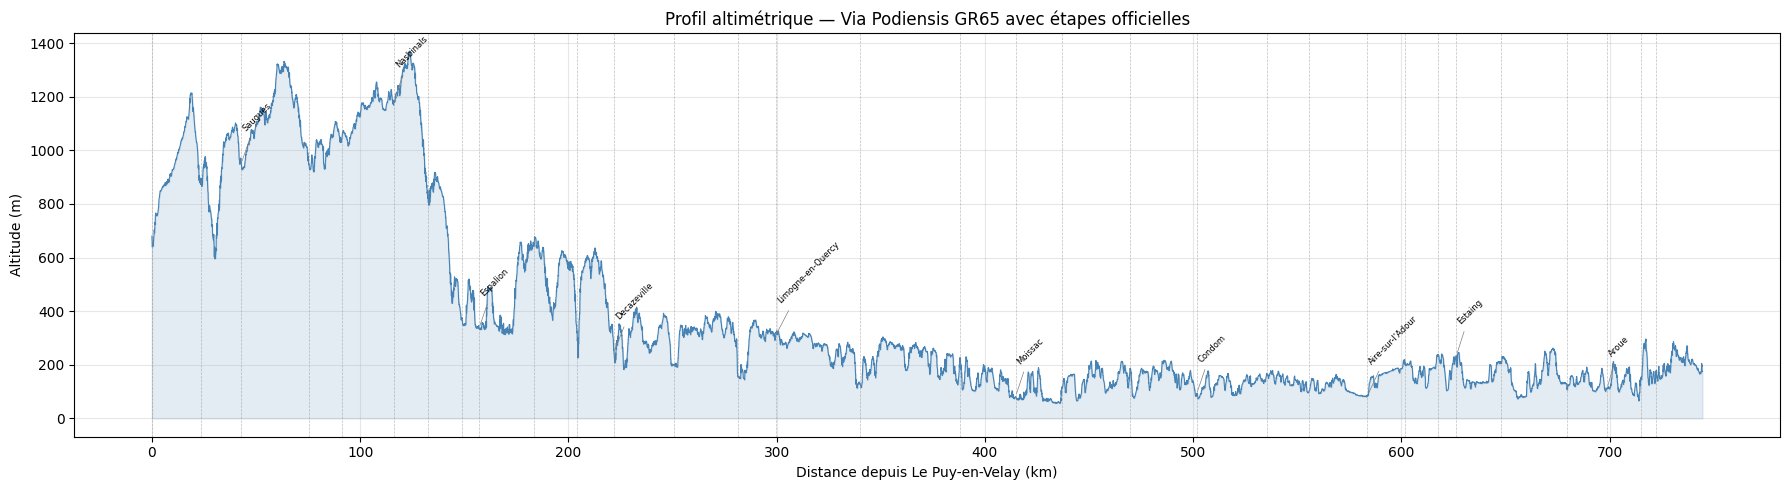

Graphique exporté : C:\Users\cello\Desktop\Via_Podiensis_geospatial\data_raw\profil_altimetrique.png


In [8]:
fig, ax = plt.subplots(figsize=(18, 5))

dist_km = df["distance_m"] / 1000
ax.plot(dist_km, df["elevation"], color="steelblue", linewidth=0.8)
ax.fill_between(dist_km, df["elevation"], alpha=0.15, color="steelblue")

# Pré-calcul des altitudes aux bornes pour éviter idxmin dans la boucle
for _, row in df_officielles.iterrows():
    idx = (dist_km - row["km_start"]).abs().idxmin()
    alt = df.loc[idx, "elevation"]
    ax.axvline(row["km_start"], color="gray", linewidth=0.5, linestyle="--", alpha=0.5)
    if row["etape"] % 3 == 0:
        ax.annotate(
            row["depart"],
            xy=(row["km_start"], alt),
            xytext=(row["km_start"], alt + 120),
            fontsize=6, rotation=45, ha="left",
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
        )

ax.set_xlabel("Distance depuis Le Puy-en-Velay (km)")
ax.set_ylabel("Altitude (m)")
ax.set_title("Profil altimétrique — Via Podiensis GR65 avec étapes officielles")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG_ALTI, dpi=150, bbox_inches="tight")
plt.show()
print(f"Graphique exporté : {OUT_FIG_ALTI}")

## 6. Résumé statistique

In [9]:
SEP = "=" * 55

print(SEP)
print("  VIA PODIENSIS GR65 — Résumé général")
print(SEP)
print(f"  Distance totale     : {TOTAL_KM:.1f} km")
print(f"  D+ total            : {df_officielles['d_plus_m'].sum():,.0f} m")
print(f"  D- total            : {df_officielles['d_minus_m'].sum():,.0f} m")
print(f"  Nb étapes           : {len(df_officielles)}")
print(f"  Distance moy/étape  : {df_officielles['distance_km'].mean():.1f} km")
print(f"  D+ moyen/étape      : {df_officielles['d_plus_m'].mean():.0f} m")

cols_affich = ["etape", "depart", "arrivee", "distance_km", "d_plus_m", "score_effort", "difficulte"]

print(f"\n{'─'*55}")
print("  5 étapes les plus difficiles")
print(f"{'─'*55}")
print(df_officielles.nlargest(5, "score_effort")[cols_affich].to_string(index=False))

print(f"\n{'─'*55}")
print("  5 étapes les plus faciles")
print(f"{'─'*55}")
print(df_officielles.nsmallest(5, "score_effort")[cols_affich].to_string(index=False))

  VIA PODIENSIS GR65 — Résumé général
  Distance totale     : 744.6 km
  D+ total            : 23,611 m
  D- total            : 24,116 m
  Nb étapes           : 32
  Distance moy/étape  : 23.3 km
  D+ moyen/étape      : 738 m

───────────────────────────────────────────────────────
  5 étapes les plus difficiles
───────────────────────────────────────────────────────
 etape            depart                   arrivee  distance_km  d_plus_m  score_effort difficulte
    16            Cahors                  Lauzerte         48.0    1542.0         0.978  Difficile
     9          Espalion                  Golinhac         26.6    1602.0         0.822  Difficile
     3           Saugues Saint-Alban-sur-Limagnole         32.3    1153.0         0.701  Difficile
    15 Limogne-en-Quercy                    Cahors         40.5     830.0         0.648  Difficile
    19          Auvillar                  Lectoure         33.0     966.0         0.637  Difficile

───────────────────────────────────

## 7. Export

In [10]:
df_officielles.to_csv(OUT_OFFICIEL, index=False)
df_custom.to_csv(OUT_CUSTOM, index=False)

print(f"Exporté : {OUT_OFFICIEL}  ({len(df_officielles)} étapes officielles)")
print(f"Exporté : {OUT_CUSTOM}  ({len(df_custom)} étapes custom [{KM_MIN}–{KM_MAX} km/j])")

Exporté : C:\Users\cello\Desktop\Via_Podiensis_geospatial\data_raw\etapes_officielles.csv  (32 étapes officielles)
Exporté : C:\Users\cello\Desktop\Via_Podiensis_geospatial\data_raw\etapes_custom.csv  (29 étapes custom [20–30 km/j])


## Conclusion

Ce notebook produit deux visions complémentaires du GR65 :

**Étapes officielles** — référence stable, validée terrain, utile comme ancrage de communication
et point de comparaison avec d'autres sources (topoguides, forums de pèlerins).

**Segmentation intelligente** — flexible, personnalisable par le pèlerin via `KM_MIN` / `KM_MAX`,
et garantie d'aboutir sur un hébergement réel. Les avertissements émis signalent les zones
peu équipées — information utile en elle-même pour anticiper une nuit en camping ou bivouac.

### Limites connues
- Les positions kilométriques des étapes officielles sont des approximations basées sur la trace GPX.
  De légères variantes existent selon les éditions du guide.
- Les hébergements OSM peuvent être incomplets ou périmés — une mise à jour manuelle
  sur les zones signalées en avertissement est recommandée avant utilisation en production.
- Le score d'effort ignore la chaleur, le vent et l'état du sol — facteurs non disponibles
  dans les données actuelles.

### Prochaine étape — Phase 4 : Dashboard Streamlit
Les deux CSV produits (`etapes_officielles.csv`, `etapes_custom.csv`) alimenteront
le dashboard interactif permettant au pèlerin de visualiser et personnaliser son itinéraire.